<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/Davisson_Germer_DTQEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Demo with T=300K
Auto‑calibrated effective gamma_t = 0.3340


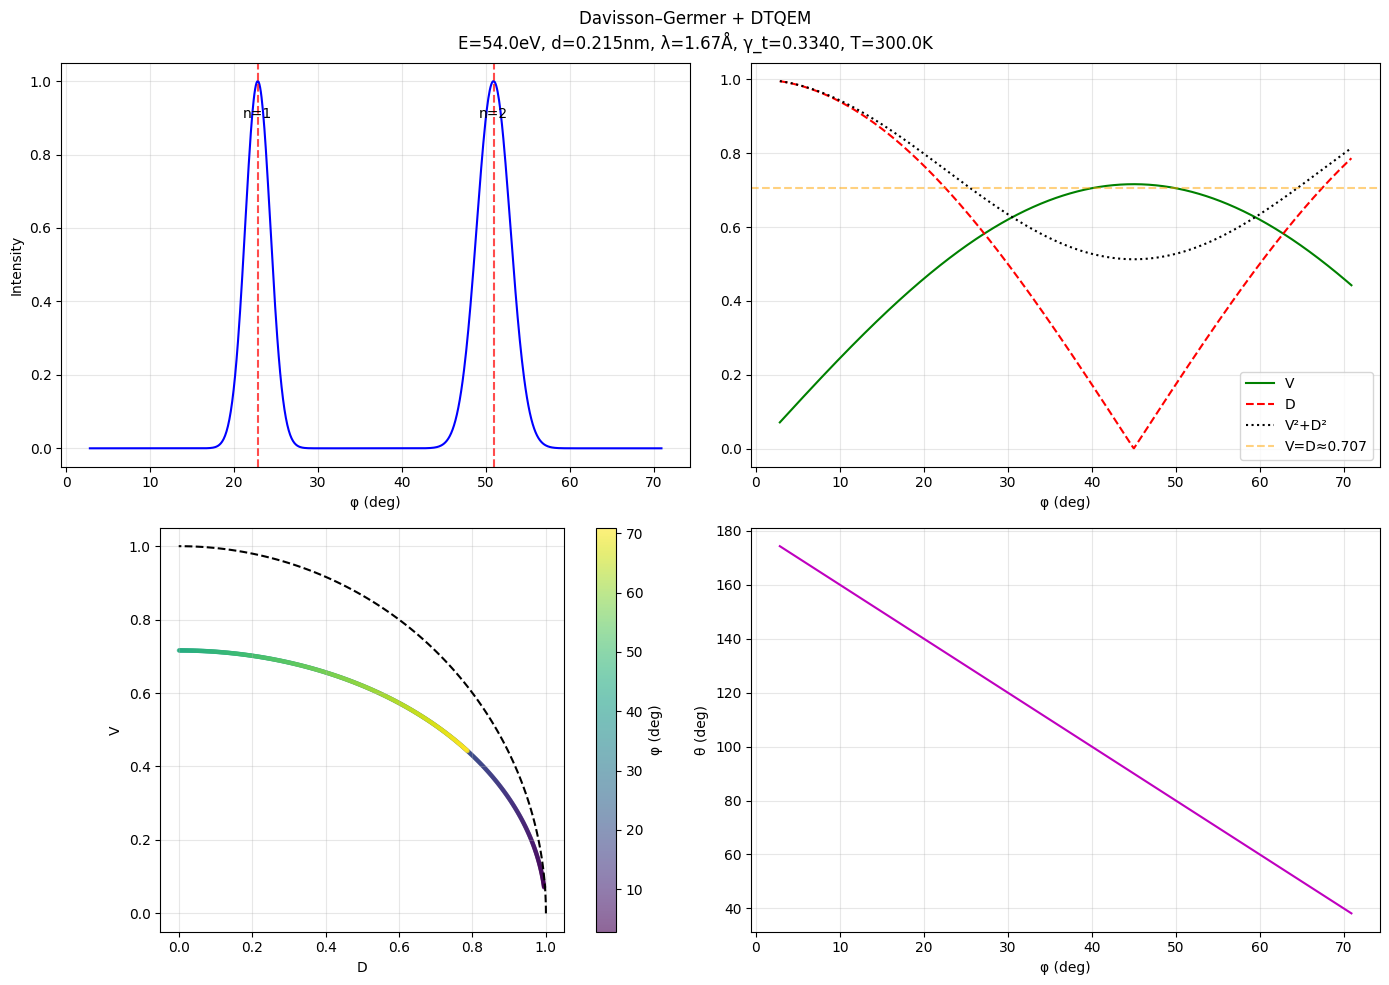


🔍 Bragg peaks:
  n=1, φ=22.84°: θ=134.27°, V=0.5127, D=0.6981, V²+D²=0.7502
  n=2, φ=50.92°: θ=78.20°, V=0.7009, D=0.2045, V²+D²=0.5331

Demo with T=500K (wider peaks, larger gamma_t, smaller V)
Auto‑calibrated effective gamma_t = 0.3695


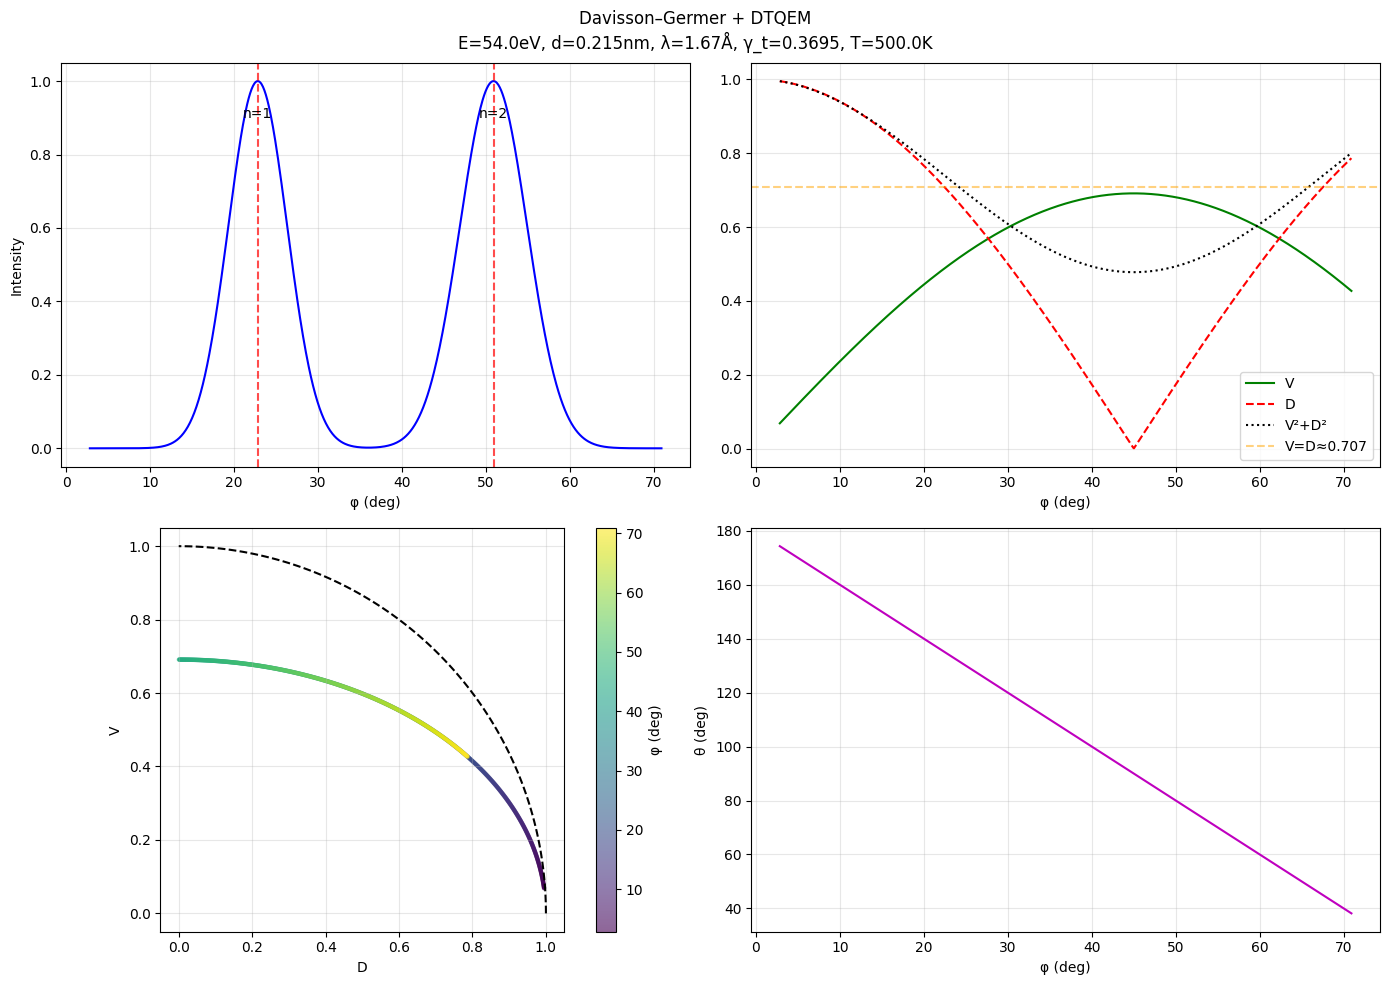


🔍 Bragg peaks:
  n=1, φ=22.84°: θ=134.27°, V=0.4949, D=0.6981, V²+D²=0.7322
  n=2, φ=50.92°: θ=78.20°, V=0.6765, D=0.2045, V²+D²=0.4995


In [1]:

# -*- coding: utf-8 -*-
"""
DTQEM for Davisson–Germer experiment with full temperature dependence.
Author: Al Moalim Berramdane (Version 1.3)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

try:
    from ipywidgets import interact, FloatSlider, IntSlider, Checkbox
    from IPython.display import display
    WIDGETS_OK = True
except ImportError:
    WIDGETS_OK = False

# ======================================================================
# CONSTANTS
# ======================================================================
h = 6.626e-34
m_e = 9.109e-31
eV = 1.602e-19
k_B = 1.381e-23

def de_broglie_wavelength(energy_eV):
    return h / np.sqrt(2 * m_e * energy_eV * eV)

def bragg_angles(d_nm, wavelength_m, n_max=3):
    d_m = d_nm * 1e-9
    angles = []
    for n in range(1, n_max+1):
        sin_phi = n * wavelength_m / (2 * d_m)
        if sin_phi <= 1:
            angles.append((n, np.degrees(np.arcsin(sin_phi))))
    return angles

def gaussian_peak(phi, phi0, sigma, amp, bg=0):
    return amp * np.exp(-((phi-phi0)**2)/(2*sigma**2)) + bg

def dtqem_params(phi_deg, gamma_t):
    phi_rad = np.radians(phi_deg)
    theta_deg = 180 - 2*phi_deg
    theta_rad = np.radians(theta_deg)
    alpha = np.cos(phi_rad)
    V = np.sin(theta_rad) * np.exp(-gamma_t)
    D = np.abs(np.cos(theta_rad))
    comp = V**2 + D**2
    if comp > 1:
        V /= np.sqrt(comp)
        D /= np.sqrt(comp)
        comp = 1.0
    return theta_deg, alpha, V, D, comp

def calibrate_gamma_t(phi_data, I_data, phi_bragg):
    """Fit gamma_t by matching V(phi) to normalized intensity."""
    mask = (phi_data > phi_bragg-15) & (phi_data < phi_bragg+15)
    phi_win = phi_data[mask]
    I_win = I_data[mask]
    if len(phi_win) < 5:
        return 0.5
    I_norm = I_win / np.max(I_win)
    def model(g):
        return np.array([dtqem_params(p, g)[2] for p in phi_win])
    def loss(g):
        pred = model(g)
        pred = pred / np.max(pred)
        return np.sum((pred - I_norm)**2)
    res = minimize_scalar(loss, bounds=(0.05, 2.0), method='bounded')
    return res.x

# ======================================================================
# MAIN SIMULATION (with temperature-dependent peak width)
# ======================================================================
def run_davisson_germmer(
    energy_eV=54.0,
    d_nm=0.215,
    gamma_t=0.5,
    auto_calibrate=True,
    n_max=3,
    use_temperature=False,
    temperature_K=300.0,
    alpha_temp=0.002,      # multiplicative factor for gamma_t
    beta_width=0.01,       # (deg/K) increase of sigma with T
    T_ref=300.0,           # reference temperature for sigma_0
    custom_phi=None,
    custom_intensity=None
):
    wavelength = de_broglie_wavelength(energy_eV)
    bragg = bragg_angles(d_nm, wavelength, n_max)

    if not bragg:
        print("No Bragg peaks.")
        return

    # Temperature scaling of gamma_t (multiplicative effect)
    if use_temperature:
        gamma_t_eff = gamma_t * (1 + alpha_temp * temperature_K)
    else:
        gamma_t_eff = gamma_t

    # Generate or use custom data
    if custom_phi is None or custom_intensity is None:
        phi_min = min(p for _, p in bragg) - 20
        phi_max = max(p for _, p in bragg) + 20
        phi_data = np.linspace(phi_min, phi_max, 800)
        I_data = np.zeros_like(phi_data)
        for n, phi0 in bragg:
            # Base sigma increases with order
            sigma0 = 1.5 + 0.5*(n-1)
            if use_temperature:
                # Increase sigma linearly with temperature above T_ref
                delta_T = temperature_K - T_ref
                sigma = sigma0 + beta_width * max(0, delta_T)
            else:
                sigma = sigma0
            I_data += gaussian_peak(phi_data, phi0, sigma, amp=1.0)
        I_data = I_data / np.max(I_data)
    else:
        phi_data = custom_phi
        I_data = custom_intensity / np.max(custom_intensity)

    # Auto-calibrate from main peak
    if auto_calibrate and bragg:
        main_phi = bragg[0][1]
        gamma_t_cal = calibrate_gamma_t(phi_data, I_data, main_phi)
        print(f"Auto‑calibrated effective gamma_t = {gamma_t_cal:.4f}")
        gamma_t_eff = gamma_t_cal

    # Compute DTQEM curves
    V_arr = []
    D_arr = []
    comp_arr = []
    theta_arr = []
    for phi in phi_data:
        th, _, V, D, comp = dtqem_params(phi, gamma_t_eff)
        theta_arr.append(th)
        V_arr.append(V)
        D_arr.append(D)
        comp_arr.append(comp)

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    temp_str = f", T={temperature_K}K" if use_temperature else ""
    fig.suptitle(f"Davisson–Germer + DTQEM\nE={energy_eV}eV, d={d_nm}nm, λ={wavelength*1e10:.2f}Å, γ_t={gamma_t_eff:.4f}{temp_str}")

    ax1 = axes[0,0]
    ax1.plot(phi_data, I_data, 'b-')
    for n, phi0 in bragg:
        ax1.axvline(phi0, color='r', linestyle='--', alpha=0.7)
        ax1.text(phi0, 0.9, f'n={n}', ha='center')
    ax1.set_xlabel('φ (deg)'); ax1.set_ylabel('Intensity'); ax1.grid(alpha=0.3)

    ax2 = axes[0,1]
    ax2.plot(phi_data, V_arr, 'g-', label='V')
    ax2.plot(phi_data, D_arr, 'r--', label='D')
    ax2.plot(phi_data, comp_arr, 'k:', label='V²+D²')
    ax2.axhline(0.707, color='orange', ls='--', alpha=0.5, label='V=D≈0.707')
    ax2.legend(); ax2.grid(alpha=0.3); ax2.set_xlabel('φ (deg)')

    ax3 = axes[1,0]
    theta_c = np.linspace(0, np.pi/2, 100)
    ax3.plot(np.cos(theta_c), np.sin(theta_c), 'k--', label='Bohr limit')
    sc = ax3.scatter(D_arr, V_arr, c=phi_data, cmap='viridis', s=5, alpha=0.6)
    ax3.set_aspect('equal'); ax3.set_xlabel('D'); ax3.set_ylabel('V'); ax3.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax3, label='φ (deg)')

    ax4 = axes[1,1]
    ax4.plot(phi_data, theta_arr, 'm-')
    ax4.set_xlabel('φ (deg)'); ax4.set_ylabel('θ (deg)'); ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print at Bragg peaks
    print("\n🔍 Bragg peaks:")
    for n, phi0 in bragg:
        idx = np.argmin(np.abs(phi_data - phi0))
        print(f"  n={n}, φ={phi0:.2f}°: θ={theta_arr[idx]:.2f}°, V={V_arr[idx]:.4f}, D={D_arr[idx]:.4f}, V²+D²={comp_arr[idx]:.4f}")

    return {'phi': phi_data, 'intensity': I_data, 'V': V_arr, 'D': D_arr, 'theta': theta_arr}

# ======================================================================
# DEMO: مقارنة بين T=300K و T=500K
# ======================================================================
if __name__ == "__main__":
    print("="*60)
    print("Demo with T=300K")
    print("="*60)
    run_davisson_germmer(energy_eV=54.0, d_nm=0.215, gamma_t=0.5,
                         auto_calibrate=True, n_max=3,
                         use_temperature=True, temperature_K=300.0,
                         beta_width=0.01)

    print("\n" + "="*60)
    print("Demo with T=500K (wider peaks, larger gamma_t, smaller V)")
    print("="*60)
    run_davisson_germmer(energy_eV=54.0, d_nm=0.215, gamma_t=0.5,
                         auto_calibrate=True, n_max=3,
                         use_temperature=True, temperature_K=500.0,
                         beta_width=0.01)